# Brain Tumor Detection System
**14-layer CNN | TensorFlow + Keras + OpenCV | Br35H Dataset**

## 1. Install & Import Dependencies

In [42]:
import os, random, json, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, roc_curve
)

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

## 2. Configuration

In [43]:
CFG = {
    'data_dir'     : 'data/br35h',
    'output_dir'   : 'outputs',
    'img_size'     : (224, 224),
    'batch_size'   : 32,
    'epochs'       : 50,
    'learning_rate': 1e-4,
    'num_classes'  : 2,
}

Path(CFG['output_dir']).mkdir(parents=True, exist_ok=True)
print('Config ready')

Config ready


## 3. Dataset Setup



In [44]:
from pathlib import Path
import random, shutil
import kagglehub

data_path = kagglehub.dataset_download("ahmedhamada0/brain-tumor-detection")
print("Dataset path:", data_path)

def split_data(src, dest="data/br35h"):
    src = Path(src)

    for cls in ["yes", "no"]:
        files = list((src / cls).glob("*"))
        files = [f for f in files if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
        random.shuffle(files)

        n = len(files)
        train = files[:int(0.7*n)]
        val   = files[int(0.7*n):int(0.85*n)]
        test  = files[int(0.85*n):]

        for split, group in zip(["train", "val", "test"], [train, val, test]):
            folder = Path(dest) / split / cls
            folder.mkdir(parents=True, exist_ok=True)
            for f in group:
                shutil.copy(f, folder / f.name)

        print(f"{cls}: train={len(train)}, val={len(val)}, test={len(test)}")

split_data(data_path)


Using Colab cache for faster access to the 'brain-tumor-detection' dataset.
Dataset path: /kaggle/input/brain-tumor-detection
yes: train=1050, val=225, test=225
no: train=1050, val=225, test=225


## 4. Preprocessing — CLAHE + Gaussian Filtering

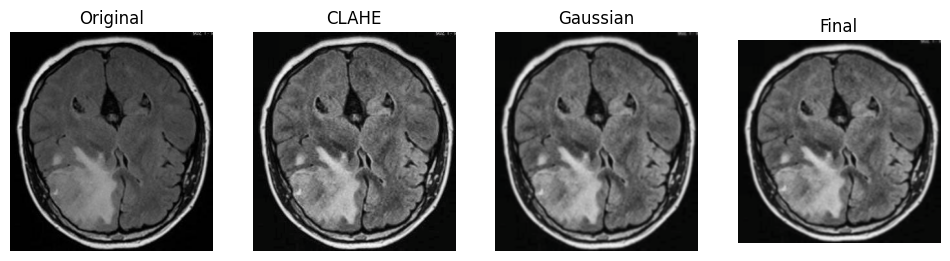

In [47]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Preprocessing of images

def clahe(img):
    lab=cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l,a,b=cv2.split(lab)
    l=cv2.createCLAHE(2.0,(8,8)).apply(l)
    return cv2.cvtColor(cv2.merge([l,a,b]),cv2.COLOR_LAB2BGR)

def denoise(img):
    return cv2.GaussianBlur(img,(5,5),1)

def skull_strip(img):
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _, th=cv2.threshold(gray,10,255,cv2.THRESH_BINARY)
    cnts, _=cv2.findContours(th,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return img
    mask=np.zeros_like(gray)
    cv2.drawContours(mask,[max(cnts,key=cv2.contourArea)],-1,255,-1)
    return cv2.bitwise_and(img,cv2.merge([mask]*3))

def preprocess(path, size=(224,224)):
    img=cv2.imread(str(path))
    img=skull_strip(img)
    img=clahe(img)
    img=denoise(img)
    img=cv2.resize(img, size)
    return img, img/255.0

# Visualization
sample=next(Path("data/br35h").rglob("*.jpg"), None)

if sample:
    img=cv2.imread(str(sample))
    c=clahe(img)
    g=denoise(c)
    f=cv2.resize(g, (224,224))

    titles=["Original","CLAHE","Gaussian","Final"]
    images=[img,c,g,f]

    plt.figure(figsize=(12,3))
    for i in range(4):
        plt.subplot(1,4,i+1)
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis("off")
    plt.show()

## 5. Data Augmentation (4×)

In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

def create_generators(data_dir, img_size=(224,224), batch_size=32):
    data_dir =Path(data_dir)

    train=ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.1,
        horizontal_flip=True
    ).flow_from_directory(
        data_dir/'train',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary'
    )

    val=ImageDataGenerator(rescale=1./255).flow_from_directory(
        data_dir/'val',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False
    )

    test=ImageDataGenerator(rescale=1./255).flow_from_directory(
        data_dir/'test',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False
    )

    print("Train:", train.samples, "| Val:", val.samples, "| Test:", test.samples)
    return train, val, test

# Run
train_gen, val_gen,test_gen=create_generators(
    CFG['data_dir'],CFG['img_size'],CFG['batch_size']
)

Found 2732 images belonging to 2 classes.
Found 824 images belonging to 2 classes.
Found 837 images belonging to 2 classes.
Train: 2732 | Val: 824 | Test: 837


## 6. Build the 14-Layer CNN

In [49]:
def build_brain_tumor_cnn(input_shape=(224,224,3)):
    inputs = keras.Input(shape=input_shape, name='mri_input')
    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv5')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv6')(x)
    x = layers.BatchNormalization(name='bn6')(x)
    x = layers.MaxPooling2D((2,2), name='pool3')(x)
    # Block 4
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv7')(x)
    x = layers.BatchNormalization(name='bn7')(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv8')(x)
    x = layers.BatchNormalization(name='bn8')(x)
    x = layers.MaxPooling2D((2,2), name='pool4')(x)
    # Head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.5, name='dropout1')(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4), name='dense1')(x)  # layer 13
    x = layers.BatchNormalization(name='bn_dense')(x)
    x = layers.Dropout(0.5, name='dropout2')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)             # layer 14
    return keras.Model(inputs, outputs, name='BrainTumorCNN_14Layer')

model = build_brain_tumor_cnn(input_shape=(*CFG['img_size'], 3))
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=CFG['learning_rate']),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc_roc', curve='ROC'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)
model.summary()
conv_dense = sum(1 for l in model.layers if 'conv' in l.name or 'dense' in l.name)
print(f'\nConv + Dense layers : {conv_dense}')
print(f'Total parameters    : {model.count_params():,}')

Model: "BrainTumorCNN_14Layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn6 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv7 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn7 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv8 (Conv2D)                  │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn8 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense (BatchNormalization)   │ (None, 512)            │         2,04

 Total params: 1,310,241 (5.00 MB)

 Trainable params: 1,307,297 (4.99 MB)

 Non-trainable params: 2,944 (11.50 KB)


Conv + Dense layers : 10
Total parameters    : 1,310,241


## 7. Train

In [20]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=f"{CFG['output_dir']}/best_model.keras",
        monitor='val_auc_roc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_auc_roc',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        f"{CFG['output_dir']}/training_log.csv"
    )
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CFG['epochs'],
    callbacks=callbacks,
    verbose=1
)

print("Training complete")

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.8452 - auc_roc: 0.9245 - loss: 0.4811 - precision: 0.8700 - recall: 0.8161
Epoch 1: val_auc_roc improved from None to 0.94349, saving model to outputs/best_model.keras

Epoch 1: finished saving model to outputs/best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 523ms/step - accuracy: 0.8500 - auc_roc: 0.9278 - loss: 0.4712 - precision: 0.8739 - recall: 0.8181 - val_accuracy: 0.8689 - val_auc_roc: 0.9435 - val_loss: 0.5283 - val_precision: 0.8074 - val_recall: 0.9689 - learning_rate: 3.0000e-05
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.8557 - auc_roc: 0.9322 - loss: 0.4627 - precision: 0.8750 - recall: 0.8336
Epoch 2: val_auc_roc did not improve from 0.94349
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 533ms/step - accuracy: 0.8519 - auc_roc: 0.9272 - loss: 0.4768 - precision: 0.8662 - recall: 0.8324 - val_accuracy: 0.8533 - val_auc_roc: 0.9244 - val_loss: 0.5634 - val_precision: 0.8193 - val_recall: 0.9067 - learn

## 8. Training History Plots

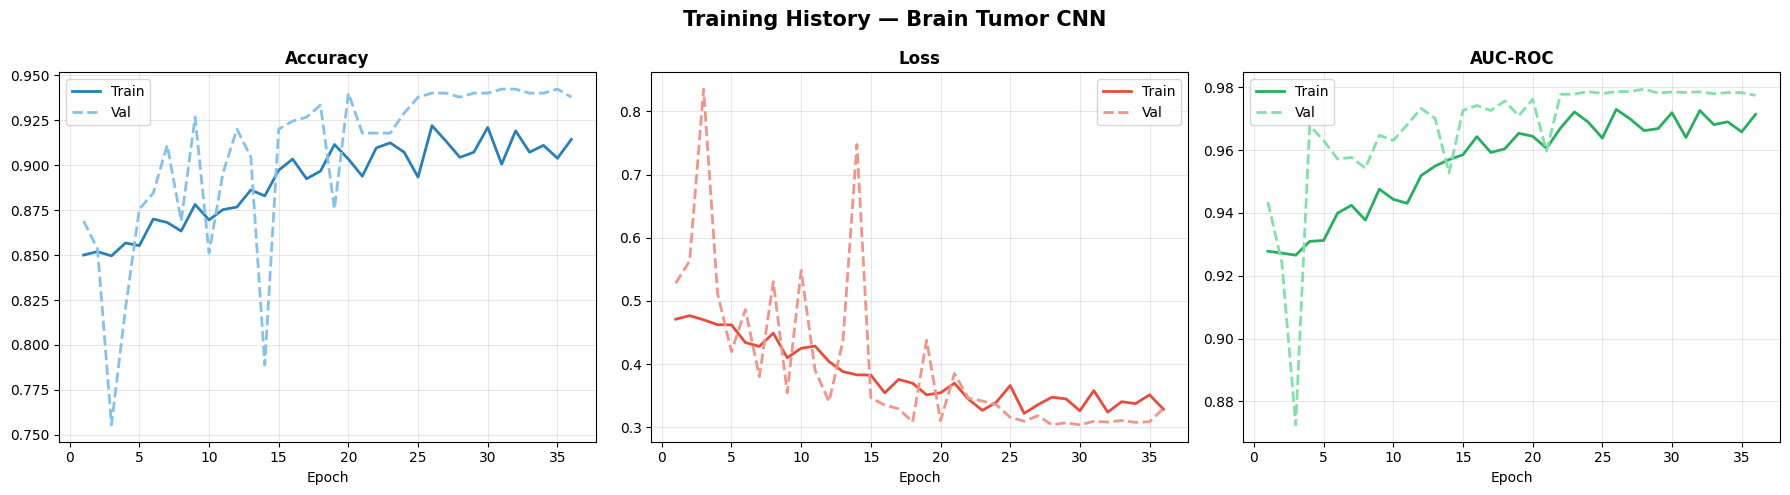

In [50]:
hist = history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — Brain Tumor CNN', fontsize=15, fontweight='bold')

pairs = [
    ('accuracy',  'val_accuracy',  'Accuracy',  '#2980b9', '#85c1e9'),
    ('loss',      'val_loss',      'Loss',      '#e74c3c', '#f1948a'),
    ('auc_roc',   'val_auc_roc',   'AUC-ROC',   '#27ae60', '#82e0aa'),
]
for ax, (tk, vk, title, c1, c2) in zip(axes, pairs):
    ax.plot(epochs_ran, hist[tk], color=c1, lw=2, label='Train')
    ax.plot(epochs_ran, hist[vk], color=c2, lw=2, linestyle='--', label='Val')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/training_history.png", dpi=150)
plt.show()

## 9. Evaluation — Accuracy · AUC-ROC · F1 · Confusion Matrix · ROC Curve

In [51]:
# Load best checkpoint for evaluation
best_model = keras.models.load_model(f"{CFG['output_dir']}/best_model.keras")

y_prob = best_model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

auc_roc  = roc_auc_score(y_true, y_prob)
f1       = f1_score(y_true, y_pred, average='weighted')
report   = classification_report(y_true, y_pred,
                                  target_names=['No Tumor', 'Tumor'],
                                  output_dict=True)
accuracy = report['accuracy']

metrics = {
    'accuracy' : round(accuracy, 4),
    'auc_roc'  : round(auc_roc,  4),
    'f1_score' : round(f1,       4),
    'precision': round(report['weighted avg']['precision'], 4),
    'recall'   : round(report['weighted avg']['recall'],    4),
}

print('\n' + '='*50)
print('  TEST SET RESULTS')
print('='*50)
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print('='*50)
print()
print(classification_report(y_true, y_pred, target_names=['No Tumor', 'Tumor']))

with open(f"{CFG['output_dir']}/metrics.json", 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved → {CFG['output_dir']}/metrics.json")

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step

  TEST SET RESULTS
  accuracy    : 0.9295
  auc_roc     : 0.9755
  f1_score    : 0.9294
  precision   : 0.9330
  recall      : 0.9295

              precision    recall  f1-score   support

    No Tumor       0.97      0.89      0.93       425
       Tumor       0.89      0.97      0.93       412

    accuracy                           0.93       837
   macro avg       0.93      0.93      0.93       837
weighted avg       0.93      0.93      0.93       837

Metrics saved → outputs/metrics.json


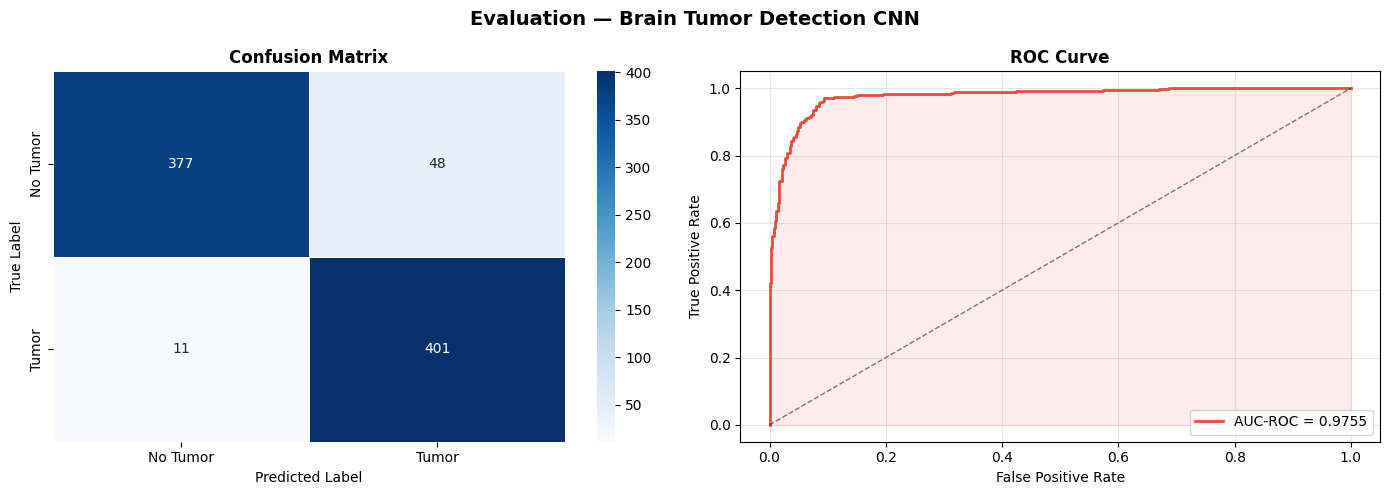

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluation — Brain Tumor Detection CNN', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Tumor','Tumor'], yticklabels=['No Tumor','Tumor'],
            linewidths=0.5)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC-ROC = {auc_roc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/evaluation.png", dpi=150)
plt.show()

## 10. Inference on New MRI Images

Processing: data/br35h/val/yes/y723.jpg


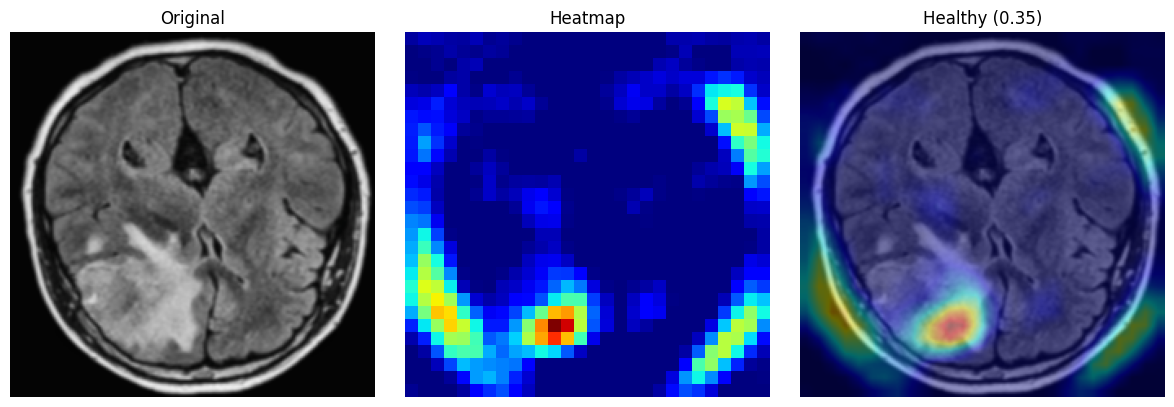

Prediction: Healthy
Probability: 0.3492


In [54]:
# Grad-CAM
def gradcam(img_array, model):
    # get last conv layer automatically
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]

    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Overlay
def overlay_heatmap(heatmap, img):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

# Full Prediction
def predict_with_gradcam(image_path):
    print(f"Processing: {image_path}")

    # Load model
    model = keras.models.load_model(MODEL_PATH)

    # Preprocess
    img_raw, img = preprocess(image_path)
    input_tensor = np.expand_dims(img, axis=0)

    # Predict
    prob = float(model.predict(input_tensor, verbose=0)[0][0])
    label = "Tumor" if prob >= 0.5 else "Healthy"

    # Grad-CAM
    heatmap = gradcam(input_tensor, model)
    overlay = overlay_heatmap(heatmap, img_raw)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"{label} ({prob:.2f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Prediction: {label}")
    print(f"Probability: {prob:.4f}")

# --- Run ---
test_image = next(Path(DATA_DIR).rglob("*.jpg"), None)

if test_image:
    predict_with_gradcam(test_image)
else:
    print("No image found in dataset ")

## 11. Save Final Model

In [55]:
final_path = f"{CFG['output_dir']}/brain_tumor_cnn_final.keras"
best_model.save(final_path)
print(f'Final model saved → {final_path}')

print('\n' + '='*50)
print('  SUMMARY')
print('='*50)
print(f"  Architecture  : 14-layer CNN (8 Conv + 2 Dense + BN)")
print(f"  Parameters    : {best_model.count_params():,}")
print(f"  Accuracy      : {metrics['accuracy']:.4f}")
print(f"  AUC-ROC       : {metrics['auc_roc']:.4f}")
print(f"  F1-Score      : {metrics['f1_score']:.4f}")
print(f"  Preprocessing : Skull strip → CLAHE → Gaussian(5×5) → Normalize")
print(f"  Augmentation  : 4× (rotation, flip, zoom, brightness, shift)")
print('='*50)

Final model saved → outputs/brain_tumor_cnn_final.keras

  SUMMARY
  Architecture  : 14-layer CNN (8 Conv + 2 Dense + BN)
  Parameters    : 1,310,241
  Accuracy      : 0.9295
  AUC-ROC       : 0.9755
  F1-Score      : 0.9294
  Preprocessing : Skull strip → CLAHE → Gaussian(5×5) → Normalize
  Augmentation  : 4× (rotation, flip, zoom, brightness, shift)
